# Data Visualization Practice

## Case Study 2: Food Delivery Analytics 

#### Business Problem
A food delivery company wants to answer:
- How are daily orders trending?
- Which city generates the highest revenue?
- Which food category is most popular?
- Does delivery time affect customer ratings?
- Which restaurants generate the highest revenue?

### Dataset

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = {
    'Order_Date': [
        '2025-06-01','2025-06-01','2025-06-02','2025-06-02',
        '2025-06-03','2025-06-03','2025-06-04','2025-06-04',
        '2025-06-05','2025-06-05'
    ],

    'City': [
        'Bangalore','Mumbai','Delhi','Bangalore',
        'Mumbai','Delhi','Bangalore','Mumbai',
        'Delhi','Bangalore'
    ],

    'Restaurant': [
        'Spice Hub','Pizza Point','Burger King','Spice Hub',
        'Pizza Point','Burger King','Spice Hub','Pizza Point',
        'Burger King','Spice Hub'
    ],

    'Category': [
        'Indian','Pizza','Burger','Indian',
        'Pizza','Burger','Indian','Pizza',
        'Burger','Indian'
    ],

    'Order_Value': [
        450,650,350,500,
        700,300,550,750,
        400,600
    ],

    'Delivery_Time': [
        25,40,18,22,
        35,20,24,38,
        19,23
    ],

    'Rating': [
        4.5,4.0,4.8,4.6,
        3.9,4.7,4.5,3.8,
        4.9,4.7
    ]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,Order_Date,City,Restaurant,Category,Order_Value,Delivery_Time,Rating
0,2025-06-01,Bangalore,Spice Hub,Indian,450,25,4.5
1,2025-06-01,Mumbai,Pizza Point,Pizza,650,40,4.0
2,2025-06-02,Delhi,Burger King,Burger,350,18,4.8
3,2025-06-02,Bangalore,Spice Hub,Indian,500,22,4.6
4,2025-06-03,Mumbai,Pizza Point,Pizza,700,35,3.9
5,2025-06-03,Delhi,Burger King,Burger,300,20,4.7
6,2025-06-04,Bangalore,Spice Hub,Indian,550,24,4.5
7,2025-06-04,Mumbai,Pizza Point,Pizza,750,38,3.8
8,2025-06-05,Delhi,Burger King,Burger,400,19,4.9
9,2025-06-05,Bangalore,Spice Hub,Indian,600,23,4.7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_Date     10 non-null     object 
 1   City           10 non-null     object 
 2   Restaurant     10 non-null     object 
 3   Category       10 non-null     object 
 4   Order_Value    10 non-null     int64  
 5   Delivery_Time  10 non-null     int64  
 6   Rating         10 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 692.0+ bytes


In [6]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

### 1: Daily Revenue Trend
- Are revenues growing day by day?

###### Data Preparation

In [8]:
daily_revenue = (df.groupby('Order_Date')['Order_Value'].sum().reset_index())

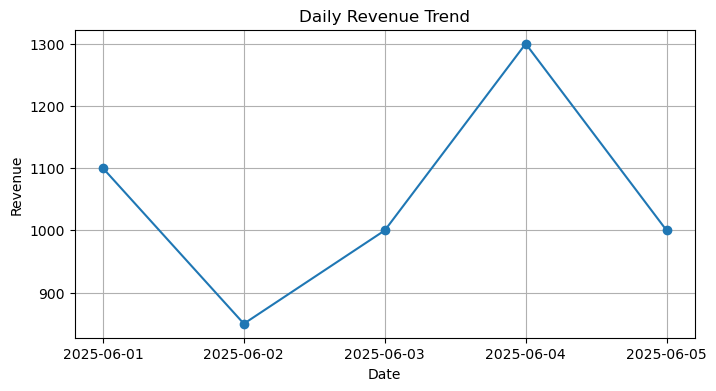

In [18]:
plt.figure(figsize=(8,4))
plt.plot(daily_revenue['Order_Date'],daily_revenue['Order_Value'],marker='o')
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(daily_revenue['Order_Date'])
plt.grid(True)
plt.show()

In [19]:
daily_revenue

,Order_Date,Order_Value
0,2025-06-01,1100
1,2025-06-02,850
2,2025-06-03,1000
3,2025-06-04,1300
4,2025-06-05,1000


### 2: Revenue by City
Which city contributes most revenue?

In [32]:
city_revenue = df.groupby('City')['Order_Value'].sum().reset_index()

In [33]:
city_revenue

,City,Order_Value
0,Bangalore,2100
1,Delhi,1050
2,Mumbai,2100


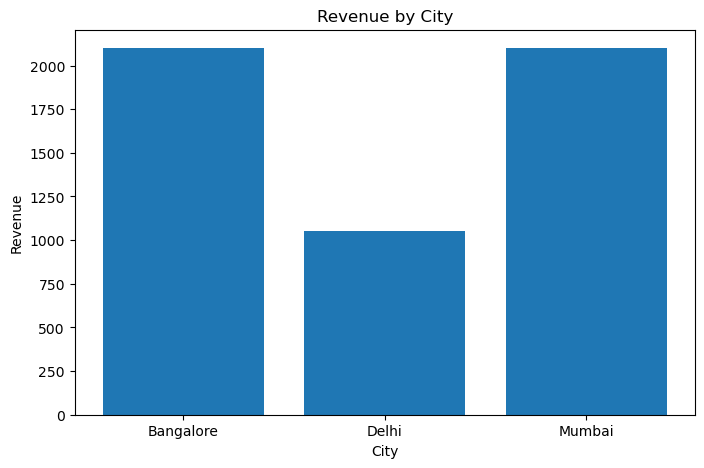

In [37]:
plt.figure(figsize=(8,5))
plt.bar(city_revenue['City'],city_revenue['Order_Value'])
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

In [38]:
city_revenue.sort_values(by='Order_Value',ascending=False, inplace=True)

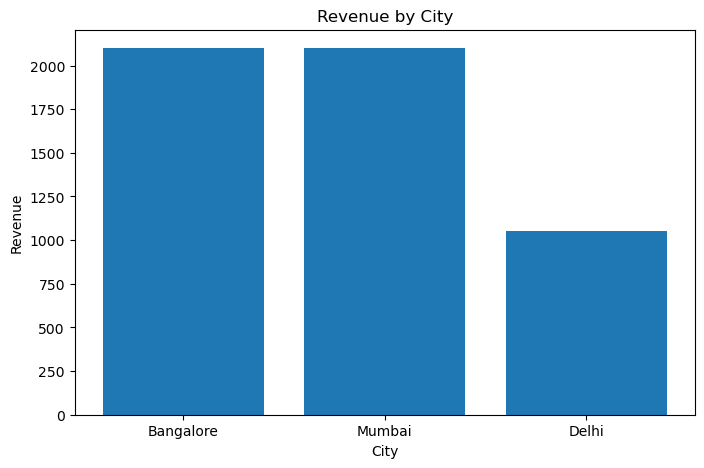

In [39]:
plt.figure(figsize=(8,5))
plt.bar(city_revenue['City'],city_revenue['Order_Value'])
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

#### 3: Most Popular Food Category
- Which cuisine drives revenue?

In [40]:
category_sales = (df.groupby('Category')['Order_Value'].sum().reset_index())

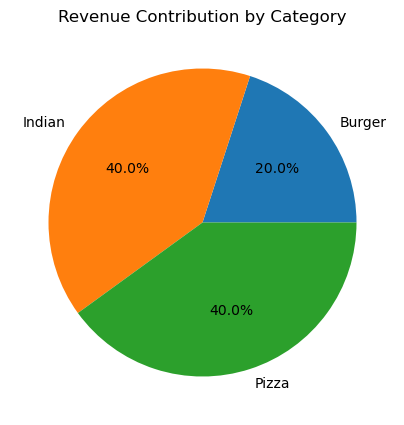

In [43]:
plt.figure(figsize=(5,5))
plt.pie(category_sales['Order_Value'],labels=category_sales['Category'],autopct='%1.1f%%')
plt.title('Revenue Contribution by Category')
plt.show()

### 4: Delivery Time vs Customer Rating
- Does slower delivery reduce ratings?

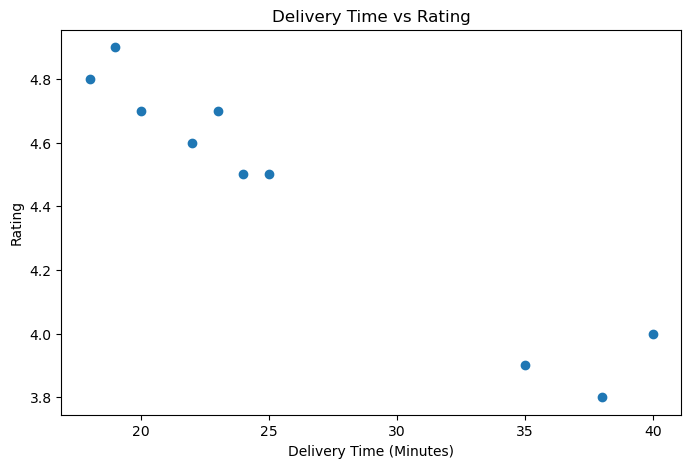

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(df['Delivery_Time'],df['Rating'])
plt.title('Delivery Time vs Rating')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Rating')
plt.show()

### 5: Restaurant Revenue Ranking

 - Which restaurants generate maximum revenue?

In [54]:
restaurant_revenue = df.groupby('Restaurant')['Order_Value'].sum().reset_index().sort_values(by='Order_Value',ascending=True)

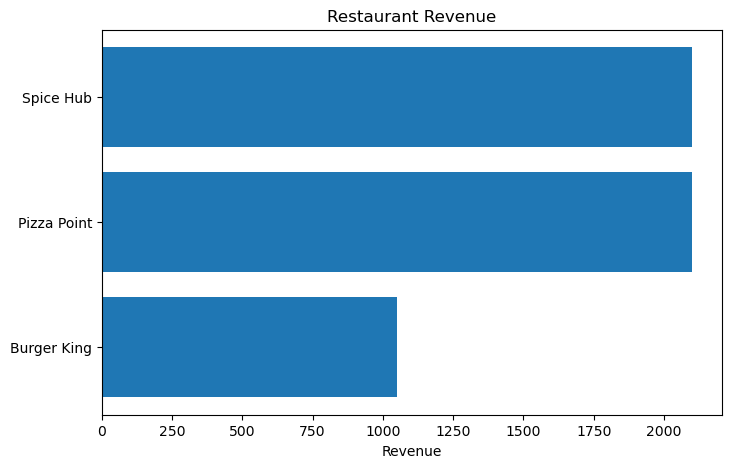

In [63]:
plt.figure(figsize=(8,5))
plt.barh(restaurant_revenue['Restaurant'],restaurant_revenue['Order_Value'])
plt.title('Restaurant Revenue')
plt.xlabel('Revenue')
plt.show()

### 6: Delivery Time Outlier Detection
- Are some deliveries taking unusually long?

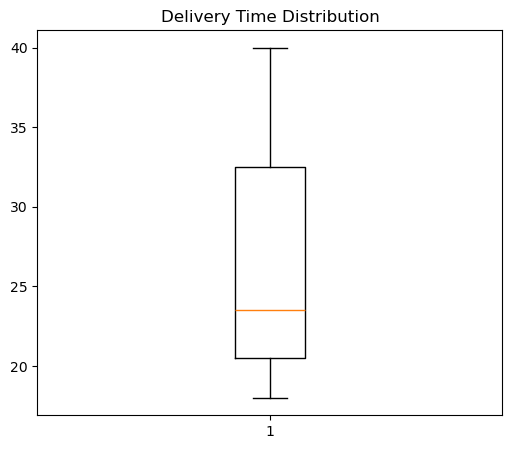

In [69]:
plt.figure(figsize=(6,5))
plt.boxplot(df['Delivery_Time'], showfliers= True)
plt.title('Delivery Time Distribution')
plt.show()